In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:

df_benign = pd.read_csv("../data/Monday-WorkingHours.pcap_ISCX.csv")
df_attack = pd.read_csv("../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df = pd.concat([df_benign, df_attack], ignore_index=True)

In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (755663, 79)
Columns: Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std',

In [5]:
print(df.head())

    Destination Port   Flow Duration   Total Fwd Packets  \
0              49188               4                   2   
1              49188               1                   2   
2              49188               1                   2   
3              49188               1                   2   
4              49486               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        0                           12   
2                        0                           12   
3                        0                           12   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             0                       6   
2                             0                       6   
3                             0                 

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755663 entries, 0 to 755662
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             755663 non-null  int64  
 1    Flow Duration                755663 non-null  int64  
 2    Total Fwd Packets            755663 non-null  int64  
 3    Total Backward Packets       755663 non-null  int64  
 4   Total Length of Fwd Packets   755663 non-null  int64  
 5    Total Length of Bwd Packets  755663 non-null  int64  
 6    Fwd Packet Length Max        755663 non-null  int64  
 7    Fwd Packet Length Min        755663 non-null  int64  
 8    Fwd Packet Length Mean       755663 non-null  float64
 9    Fwd Packet Length Std        755663 non-null  float64
 10  Bwd Packet Length Max         755663 non-null  int64  
 11   Bwd Packet Length Min        755663 non-null  int64  
 12   Bwd Packet Length Mean       755663 non-nul

In [7]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [8]:
df.columns = df.columns.str.strip()

Before Encoding:
 Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64
After Encoding:
 Label
0    627636
1    128027
Name: count, dtype: int64


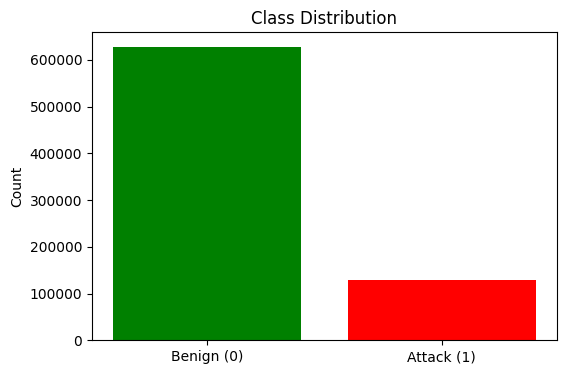

In [9]:
# Endcode Labels (Normal = 0, Attack = 1)
print("Before Encoding:\n", df['Label'].value_counts())
df['Label'] = df['Label'].apply(lambda x: 0 if str(x).strip().upper() == "BENIGN" else 1)
print("After Encoding:\n", df['Label'].value_counts())
plt.figure(figsize=(6,4))
plt.bar(['Benign (0)', 'Attack (1)'], df['Label'].value_counts(), color=['Green', 'Red'])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

In [10]:
df = df.drop_duplicates()
df=df.replace([np.inf, -np.inf], np.nan)
df=df.dropna()
print("Duplicates rows", df.duplicated().sum())

Duplicates rows 0


In [11]:
X = df.drop("Label", axis=1)
y = df["Label"]
X = pd.get_dummies(X, drop_first=True)

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
print("Class distribution in dataset:")
print(df['Label'].value_counts())
print("y_train distribution:")
print(pd.Series(y_train).value_counts())
print("y_test distribution:")
print(pd.Series(y_test).value_counts())

Class distribution in dataset:
Label
0    597660
1    128014
Name: count, dtype: int64
y_train distribution:
Label
0    418361
1     89610
Name: count, dtype: int64
y_test distribution:
Label
0    179299
1     38404
Name: count, dtype: int64


In [14]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_power = scaler.transform(X_test)

In [15]:
# Models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced',random_state=42),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100),
}
results = []

plt.figure(figsize=(8,6))
for name, model in models.items():
    print(f"\n Training & Evaluating: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test_power)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))


 Training & Evaluating: Logistic Regression
Accuracy: 0.9867388138886465
Confusion Matrix:
 [[176445   2854]
 [    33  38371]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9841    0.9919    179299
           1     0.9308    0.9991    0.9637     38404

    accuracy                         0.9867    217703
   macro avg     0.9653    0.9916    0.9778    217703
weighted avg     0.9876    0.9867    0.9869    217703


 Training & Evaluating: Random Forest
Accuracy: 0.999917318548665
Confusion Matrix:
 [[179296      3]
 [    15  38389]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9999    1.0000    0.9999    179299
           1     0.9999    0.9996    0.9998     38404

    accuracy                         0.9999    217703
   macro avg     0.9999    0.9998    0.9999    217703
weighted avg     0.9999    0.9999    0.9999    217703


 Training & Evaluating: Decision Tree
Accuracy: 

<Figure size 800x600 with 0 Axes>

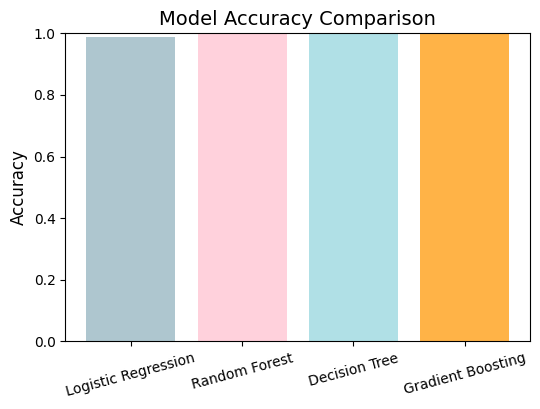

Accuracy {'Logistic Regression': 0.9867388138886465, 'Random Forest': 0.999917318548665, 'Decision Tree': 0.9998851646509235, 'Gradient Boosting': 0.9998530107531821}


In [16]:
pastel_colors = ['#AEC6CF', '#FFD1DC', '#B0E0E6', '#FFB347']  
plt.figure(figsize=(6, 4))
plt.bar(models.keys(), 
        [accuracy_score(y_test, model.predict(X_test_power)) for model in models.values()], 
        color=pastel_colors)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

print("Accuracy",{name: accuracy_score(y_test, model.predict(X_test_power)) for name, model in models.items()})

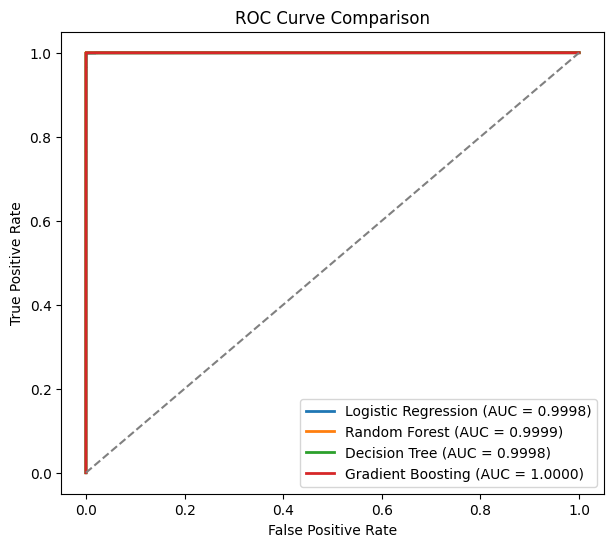

In [17]:
plt.figure(figsize=(7, 6))
for name, model in models.items():
    # Predict probabilities
    y_pred_proba = model.predict_proba(X_test_power)[:, 1]

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

# Plot settings
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

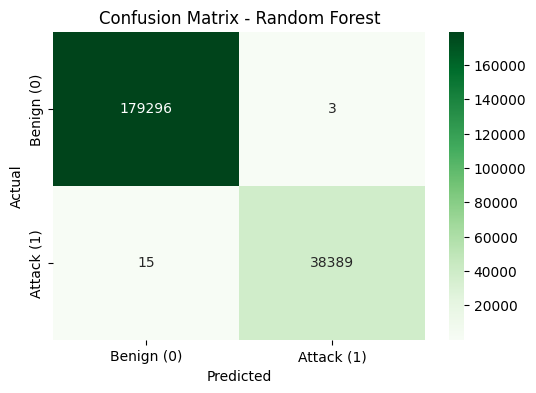

Confusion Matrix Accuracy (Random Forest): 99.99%


In [18]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_power)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign (0)', 'Attack (1)'],
            yticklabels=['Benign (0)', 'Attack (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy from confusion matrix
accuracy_from_cm = (cm[0, 0] + cm[1, 1]) / cm.sum()
print(f"Confusion Matrix Accuracy (Random Forest): {accuracy_from_cm * 100:.2f}%")

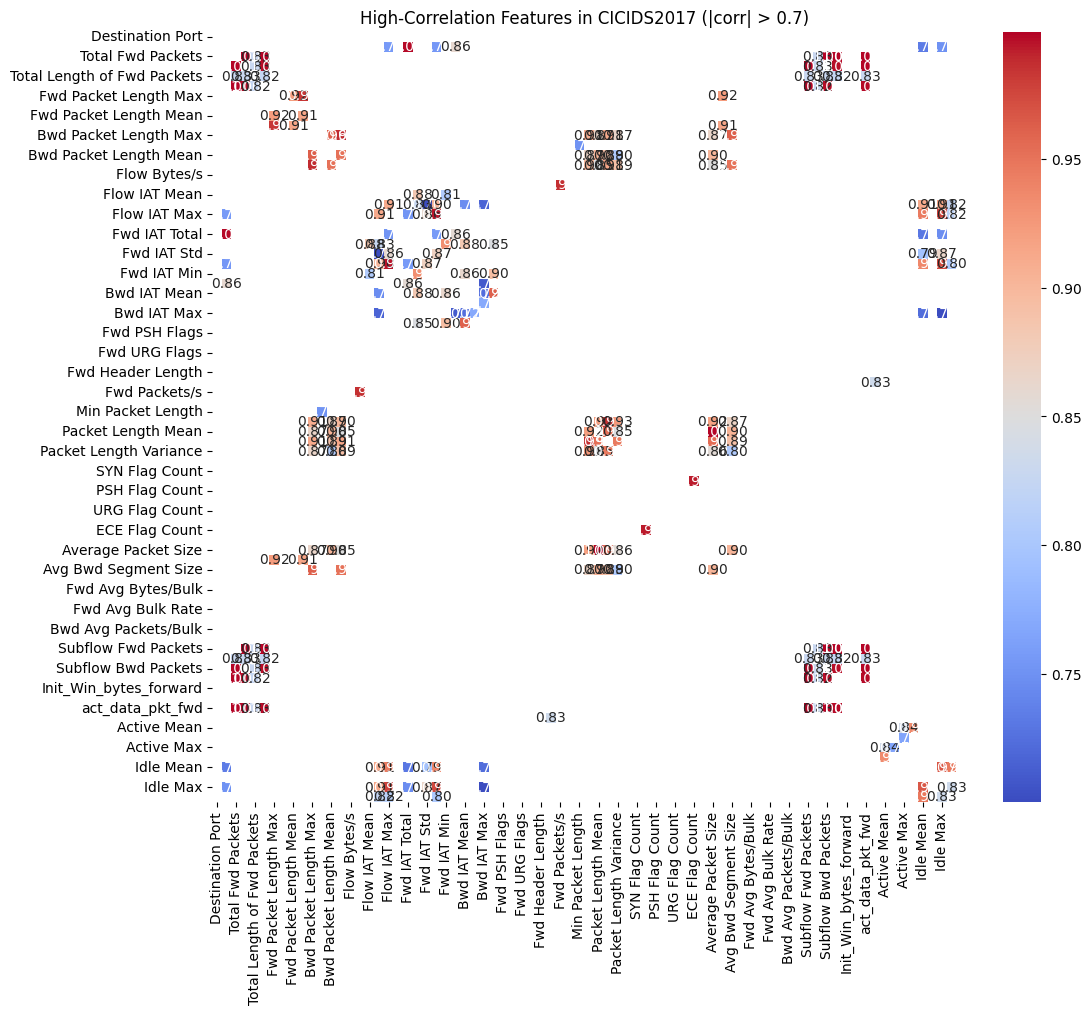

In [20]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Now compute correlation
plt.figure(figsize=(12, 10))
corr = X_train_df.corr()
high_corr = corr[(corr.abs() > 0.7) & (corr != 1.0)]

# Heatmap
sns.heatmap(high_corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("High-Correlation Features in CICIDS2017 (|corr| > 0.7)")
plt.show()
